# Baseline vs Versioned YOLO Models — Metric Comparison

Compares **baseline** (YOLOv8n) against the three versioned models (**YOLOv8**, **YOLOv9**, **YOLOv10**) across four metrics:

| Metric | Source |
|---|---|
| **Precision** | `model_rankings.csv` — evaluated on VisDrone test set |
| **Recall** | `model_rankings.csv` — evaluated on VisDrone test set |
| **Model size** | `.pt` file size on disk (MB) |
| **Training time** | Cumulative wall-clock time at final epoch from `results.csv` (seconds) |

In [9]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Paths (notebook lives in analyze/, project root is one level up) ──────────
ANALYZE_DIR  = Path(".").resolve()
ROOT         = ANALYZE_DIR.parent
MODELS_DIR   = ROOT / "models"
RESULTS_DIR  = ROOT / "results"
RANKINGS_CSV = ANALYZE_DIR / "model_rankings.csv"

print(f"Project root : {ROOT}")
print(f"Rankings CSV : {RANKINGS_CSV}")

Project root : /Users/samsikora/Desktop/Desktop/UBC/4.2/CMPE 401/Assignments/Yolo/yolo-object-detection-model-analysis
Rankings CSV : /Users/samsikora/Desktop/Desktop/UBC/4.2/CMPE 401/Assignments/Yolo/yolo-object-detection-model-analysis/analyze/model_rankings.csv


## 1 — Load & assemble metrics

In [10]:
# ── Model registry ─────────────────────────────────────────────────────────────
MODEL_CONFIG = {
    "Baseline\n(YOLOv11)": {
        "weights":     MODELS_DIR / "baseline.pt",
        "results_csv": RESULTS_DIR / "baseline" / "results.csv",
        "color":       "#4e9af1",
    },
    "YOLOv8": {
        "weights":     MODELS_DIR / "verisoned" / "yolov8.pt",
        "results_csv": RESULTS_DIR / "versioned" / "yolov8" / "results.csv",
        "color":       "#f4a742",
    },
    "YOLOv9": {
        "weights":     MODELS_DIR / "verisoned" / "yolov9.pt",
        "results_csv": RESULTS_DIR / "versioned" / "yolov9" / "results.csv",
        "color":       "#6dcf7f",
    },
    "YOLOv10": {
        "weights":     MODELS_DIR / "verisoned" / "yolov10.pt",
        "results_csv": RESULTS_DIR / "versioned" / "yolov10" / "results.csv",
        "color":       "#e06caa",
    },
}

# Key names as they appear in model_rankings.csv
RANKINGS_KEY = {
    "Baseline\n(YOLOv11)": "baseline",
    "YOLOv8":              "yolov8",
    "YOLOv9":              "yolov9",
    "YOLOv10":             "yolov10",
}

# ── Load test-set evaluation results ──────────────────────────────────────────
rankings = pd.read_csv(RANKINGS_CSV).set_index("model")

# ── Build comparison DataFrame ────────────────────────────────────────────────
records = []
for label, cfg in MODEL_CONFIG.items():
    rank_key = RANKINGS_KEY[label]

    # Precision & Recall (test-set evaluation)
    precision = rankings.loc[rank_key, "precision"]
    recall    = rankings.loc[rank_key, "recall"]

    # Model size (MB)
    size_mb = os.path.getsize(cfg["weights"]) / 1e6

    # Training time — cumulative seconds at the final epoch
    df_train = pd.read_csv(cfg["results_csv"])
    df_train.columns = df_train.columns.str.strip()
    train_time_s = df_train["time"].iloc[-1]          # seconds
    train_time_m = train_time_s / 60                  # minutes (for display)

    records.append({
        "Model":              label,
        "Precision":          precision,
        "Recall":             recall,
        "Model Size (MB)":    round(size_mb, 2),
        "Training Time (s)":  round(train_time_s, 1),
        "Training Time (min)": round(train_time_m, 1),
        "color":              cfg["color"],
    })

df = pd.DataFrame(records)
display_cols = ["Model", "Precision", "Recall", "Model Size (MB)", "Training Time (min)"]
print(df[display_cols].to_string(index=False))

              Model  Precision  Recall  Model Size (MB)  Training Time (min)
Baseline\n(YOLOv11)     0.4495  0.3467            19.16                 90.1
             YOLOv8     0.4513  0.3360            22.50                 65.6
             YOLOv9     0.4396  0.3479            15.21                 53.6
            YOLOv10     0.4312  0.3512            16.51                 66.7


## 2 — Four-metric comparison chart

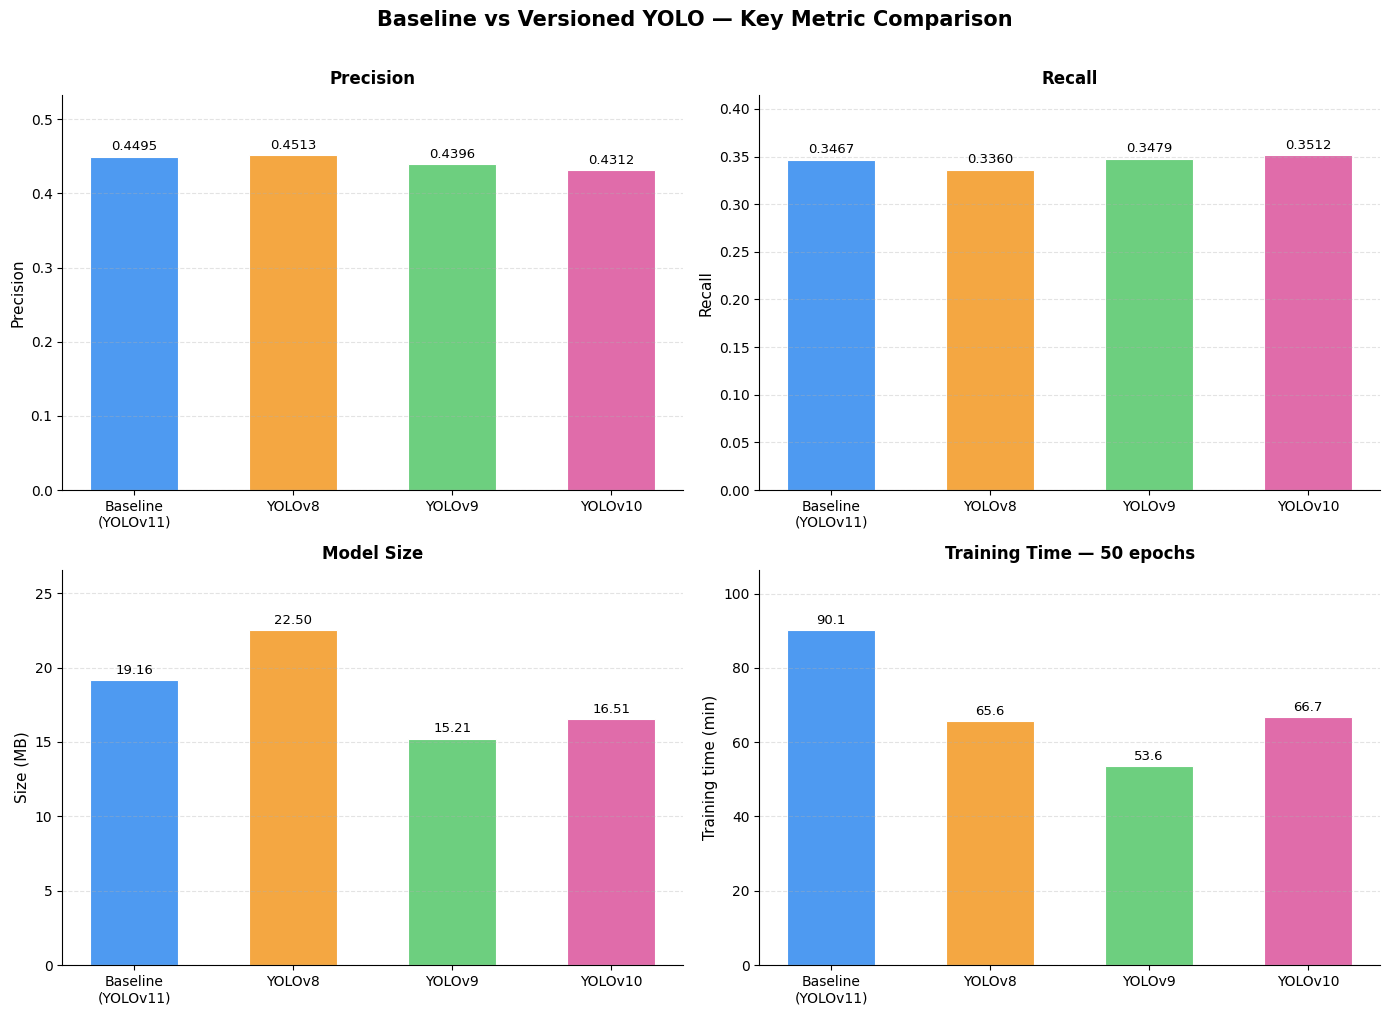

Saved → /Users/samsikora/Desktop/Desktop/UBC/4.2/CMPE 401/Assignments/Yolo/yolo-object-detection-model-analysis/results/comparison_baseline_versioned.png


In [11]:
labels  = [r.replace("\n", "\n") for r in df["Model"]]
colors  = df["color"].tolist()
x       = np.arange(len(labels))
bar_w   = 0.55

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Baseline vs Versioned YOLO — Key Metric Comparison",
    fontsize=15, fontweight="bold", y=1.01
)

def bar_chart(ax, values, ylabel, title, fmt=".4f", ypad_frac=0.15):
    bars = ax.bar(x, values, width=bar_w, color=colors, edgecolor="white", linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    ax.grid(axis="y", alpha=0.35, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)

    y_max = max(values)
    ax.set_ylim(0, y_max * (1 + ypad_frac))

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_max * 0.01,
            f"{val:{fmt}}", ha="center", va="bottom", fontsize=9.5
        )

# ── Precision ────────────────────────────────────────────────────────────────
bar_chart(
    axes[0, 0],
    df["Precision"].tolist(),
    ylabel="Precision",
    title="Precision",
    fmt=".4f",
    ypad_frac=0.18,
)

# ── Recall ───────────────────────────────────────────────────────────────────
bar_chart(
    axes[0, 1],
    df["Recall"].tolist(),
    ylabel="Recall",
    title="Recall",
    fmt=".4f",
    ypad_frac=0.18,
)

# ── Model Size ───────────────────────────────────────────────────────────────
bar_chart(
    axes[1, 0],
    df["Model Size (MB)"].tolist(),
    ylabel="Size (MB)",
    title="Model Size",
    fmt=".2f",
    ypad_frac=0.18,
)

# ── Training Time ─────────────────────────────────────────────────────────────
bar_chart(
    axes[1, 1],
    df["Training Time (min)"].tolist(),
    ylabel="Training time (min)",
    title="Training Time — 50 epochs",
    fmt=".1f",
    ypad_frac=0.18,
)

plt.tight_layout()

out_path = ANALYZE_DIR.parent / "results" / "comparison_baseline_versioned.png"
plt.savefig(out_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved → {out_path}")